In [270]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime
from refractiveindex import RefractiveIndexMaterial

### We plot experimentally obtained dielectric constants for Silica and Gold

In [12]:
Silica = RefractiveIndexMaterial(shelf='main', book='SiO2', page='Franta')
Gold = RefractiveIndexMaterial(shelf='main', book='Au', page='Johnson')
wavelengths_nm = linspace(500, 800, 301)  # [nm]

silica_epsilon = Silica.get_epsilon(wavelengths_nm)
gold_epsilon = Gold.get_epsilon(wavelengths_nm)

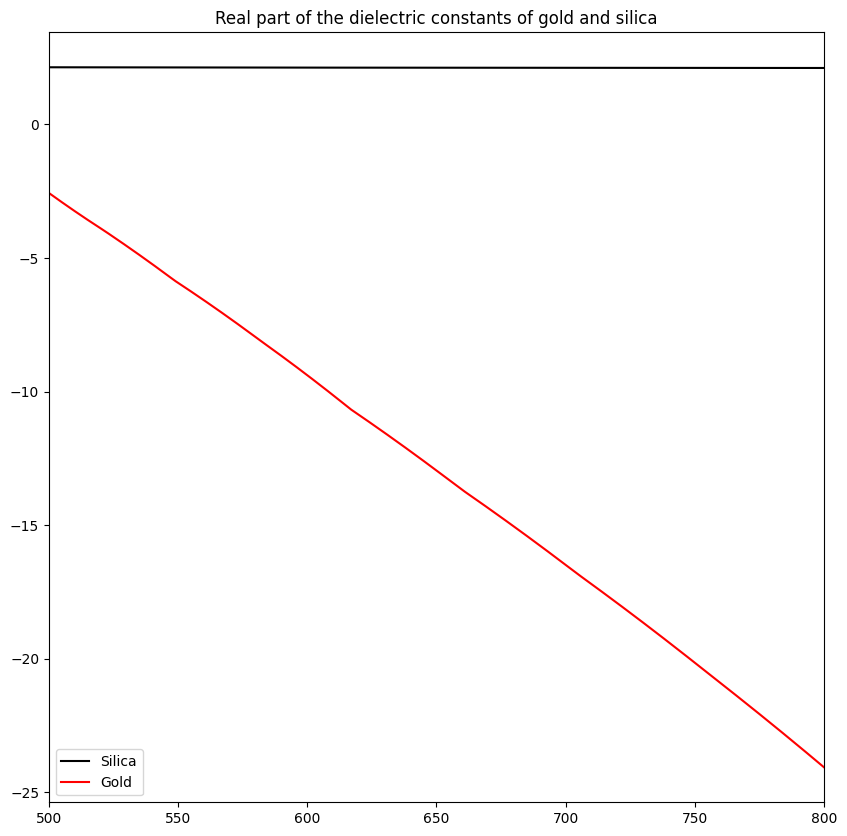

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(wavelengths_nm, silica_epsilon.real, color="black", label="Silica")
ax.plot(wavelengths_nm, gold_epsilon.real, color="red", label="Gold")
ax.set_xlim(500, 800);
ax.set_title("Real part of the dielectric constants of gold and silica")
ax.legend();

### Below, we define a recursive function to model multilayer systems

In [182]:
def recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR):

    x = sqrt(epsilon2) * kR
    y = sqrt(epsilon1) * kR
    
    mat1_11 = hl1(l, y)
    mat1_12 = hl2(l, y)
    
    yhl1_prime = hl1(l, y) + y * hl1prime(l, y)
    yhl2_prime = hl2(l, y) + y * hl2prime(l, y)
    
    mat1_21 = epsilon2 * yhl1_prime
    mat1_22 = epsilon2 * yhl2_prime
    
    xhl1_prime = hl1(l, x) + x * hl1prime(l, x)
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    
    mat2_11 = epsilon1 * xhl2_prime
    mat2_12 = -hl2(l, x)
    
    mat2_21 = -epsilon1 * xhl1_prime
    mat2_22 = hl1(l, x)
    
    
    mat1 = np.array([[mat1_11, mat1_12], [mat1_21, mat1_22]])
    mat2 = np.array([[mat2_11, mat2_12], [mat2_21, mat2_22]])
    
    next_coefficients = np.einsum("ij..., jk..., k...->i...", mat2, mat1, previous_coefficients)

    return next_coefficients

### Below is just a sanity check (should make last plot in cpa for spheres.ipynb

In [286]:
M = 200
N = 200
K = 100

real_eps_v = linspace(-3, -1.5, N, endpoint=True)
im_eps_v = linspace(0.01, 3, M, endpoint=True)
epsilon_arr = real_eps_v.reshape((N, 1)).repeat(M,1) + 1j * im_eps_v.reshape((1, M)).repeat(N, 0);
kRs = linspace(0.01, 1, K, endpoint=True)

best_real_epsilons = []
best_imaginary_epsilons = []

for (i, kR) in enumerate(kRs):
    scattering_amplitudes = np.zeros((N, M))
    previous_coefficients = np.array([1, 1])
    epsilon2 = np.ones((N, M)); epsilon1 = epsilon_arr 

    next_coefficients = recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    idx = scattering_amplitudes.argmin()
    row, col = unravel_index(idx, epsilon_arr.shape)
    best_real_epsilons.append(real_eps_v[row])
    best_imaginary_epsilons.append(im_eps_v[col])

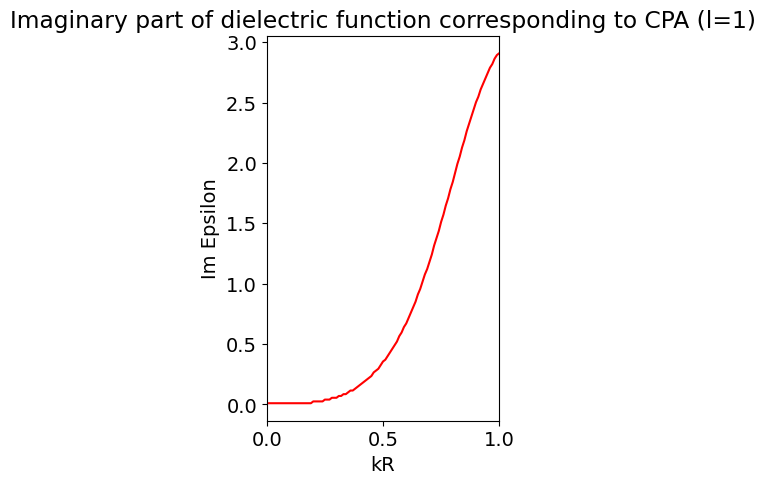

In [289]:
plt.rcParams.update({'font.size': 14})

plt.figure(figsize=(3, 5))
plt.plot(kRs, best_imaginary_epsilons, color="red")
plt.xlabel("kR")
plt.ylabel("Im Epsilon")
plt.xlim(0, 1);
plt.title("Imaginary part of dielectric function corresponding to CPA (l=1)");

In [273]:
K = 20
R_c_ratios = linspace(0.5, 0.9, K, endpoint=True)
Rs = linspace(10, 80, N, endpoint=True)
wavelengths = linspace(500, 800, M, endpoint=True)

silica_epsilon = Silica.get_epsilon(wavelengths)
gold_epsilon = Gold.get_epsilon(wavelengths)

best_wavelengths = array([])
best_Rs = array([])
for (i, R_c_ratio) in enumerate(R_c_ratios): 

    scattering_amplitudes = np.zeros((N, M))
    previous_coefficients = np.array([1, 1])
    
    epsilon2 = gold_epsilon.reshape((1, M)).repeat(N, 0) ; epsilon1 = silica_epsilon.reshape((1, M)).repeat(N, 0) 
    kR = (2*pi/wavelengths).reshape((1, M)).repeat(N, 0) * Rs.reshape((N, 1)).repeat(M, 1) * R_c_ratio
    next_coefficients = recursive_cpa(previous_coefficients, l, epsilon1, epsilon2, kR)

    epsilon2 = ones(N).reshape((1, M)).repeat(N, 0) ; epsilon1 = gold_epsilon.reshape((1, M)).repeat(N, 0) 
    kR = (2*pi/wavelengths).reshape((1, M)).repeat(N, 0) * Rs.reshape((N, 1)).repeat(M, 1) 
    next_coefficients = recursive_cpa(next_coefficients, l, epsilon1, epsilon2, kR)
    
    scattering_amplitudes = np.abs(next_coefficients[0, ...]/next_coefficients[1, ...])**2
    idx = scattering_amplitudes.argmin()
    row, col = unravel_index(idx, epsilon2.shape)
    best_Rs = np.append(best_Rs, Rs[row])
    best_wavelengths = np.append(best_wavelengths, wavelengths[col])


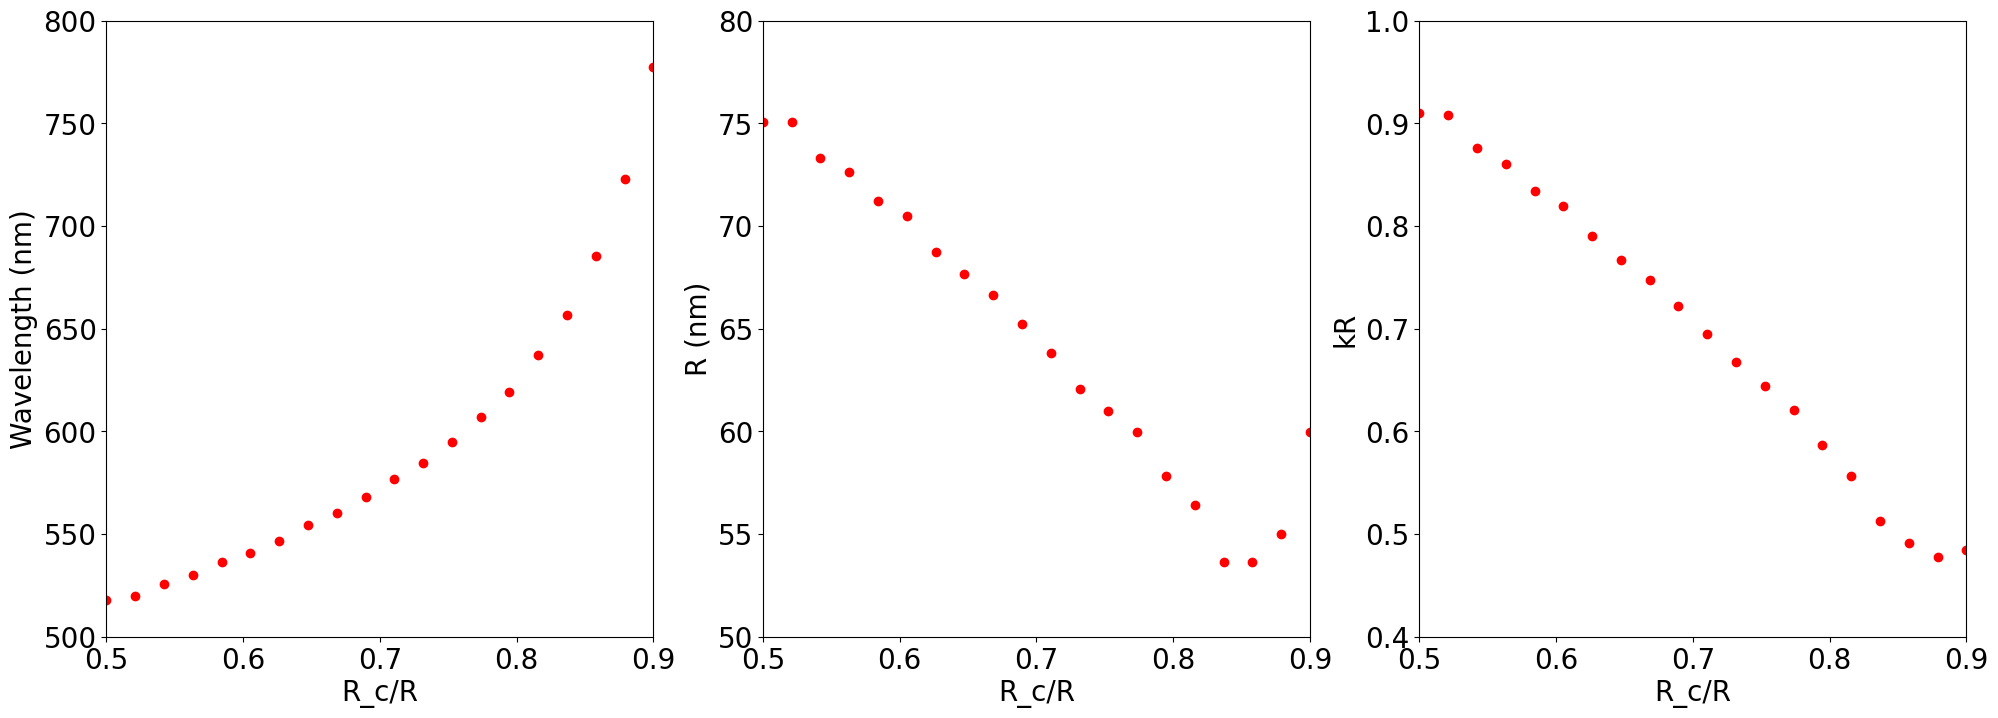

In [285]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
ax1.scatter(R_c_ratios, best_wavelengths, color="red")
ax2.scatter(R_c_ratios, best_Rs, color="red")
ax3.scatter(R_c_ratios, (2*pi/best_wavelengths)*best_Rs, color="red")
ax1.set_xlim(0.5, 0.9)
ax2.set_xlim(0.5, 0.9)
ax3.set_xlim(0.5, 0.9)

ax1.set_ylim(500, 800)
ax2.set_ylim(50, 80)
ax3.set_ylim(0.4, 1);

ax1.set_xlabel("R_c/R");
ax2.set_xlabel("R_c/R");
ax3.set_xlabel("R_c/R");

ax1.set_ylabel("Wavelength (nm)");
ax2.set_ylabel("R (nm)");
ax3.set_ylabel("kR");

